Using device: cuda
Fetched 1258 daily rows of data from FMP.
Saved raw data to 'aapl.csv'.
Data after computing indicators: (1239, 12)
Final X shape: (1234, 5, 9)
Final y shape: (1234,)

===== Fold 1 =====
Train range: 0 to 410, Val range: 411 to 821
Epoch [1/40], Train Loss: 0.061437, Val Loss (scaled): 0.005753
Epoch [2/40], Train Loss: 0.016847, Val Loss (scaled): 0.053998
Epoch [3/40], Train Loss: 0.011496, Val Loss (scaled): 0.013125
Epoch [4/40], Train Loss: 0.008395, Val Loss (scaled): 0.018553
Epoch [5/40], Train Loss: 0.005463, Val Loss (scaled): 0.006430
Epoch [6/40], Train Loss: 0.002252, Val Loss (scaled): 0.000952
Epoch [7/40], Train Loss: 0.001409, Val Loss (scaled): 0.001277
Epoch [8/40], Train Loss: 0.001026, Val Loss (scaled): 0.000771
Epoch [9/40], Train Loss: 0.000989, Val Loss (scaled): 0.000940
Epoch [10/40], Train Loss: 0.000802, Val Loss (scaled): 0.001171
Epoch [11/40], Train Loss: 0.000812, Val Loss (scaled): 0.001622
Epoch [12/40], Train Loss: 0.000745, Val Lo

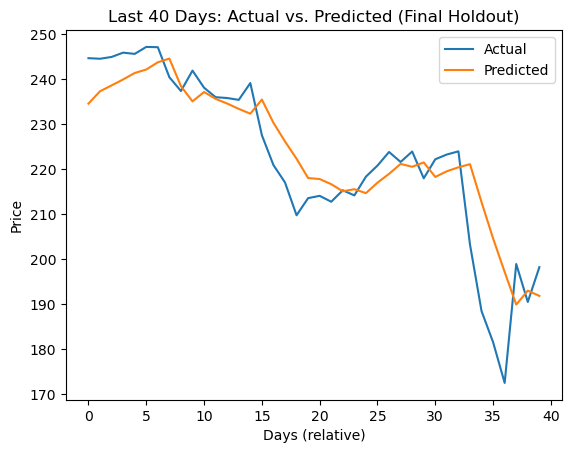


Classification Report (using median threshold to discretize continuous predictions):
              precision    recall  f1-score   support

        down       0.77      0.94      0.85        50
          up       0.92      0.72      0.81        50

    accuracy                           0.83       100
   macro avg       0.85      0.83      0.83       100
weighted avg       0.85      0.83      0.83       100



In [ ]:
import requests  
import pandas as pd 
import numpy as np  
import torch  
import torch.nn as nn  
import torch.optim as optim 
from torch.utils.data import Dataset, DataLoader  
from sklearn.preprocessing import MinMaxScaler  
from sklearn.metrics import r2_score, mean_absolute_percentage_error, classification_report  
import matplotlib.pyplot as plt  

# 1: Fetch Data from FMP API
def fetch_data_fmp(ticker, api_key):
    """
    Fetches daily historical stock data for the given ticker using FMP's API.
    Returns a Pandas DataFrame with the date set as the index.
    """
    url = f"https://financialmodelingprep.com/api/v3/historical-price-full/{ticker}?apikey={api_key}"  # Construct URL
    response = requests.get(url)
    if response.status_code != 200:
        raise ValueError(f"Request failed with status code {response.status_code}")
    
    data = response.json()
    
    # Validate that the expected key exists and is a list
    if "historical" not in data or not isinstance(data["historical"], list):
        raise ValueError(f"Unexpected response for {ticker}: {data}")
    
    records = data["historical"]  # Get historical records
    if len(records) == 0:
        raise ValueError(f"No daily data returned for {ticker}.")
    
    df = pd.DataFrame(records)  # Convert list of records to DataFrame
    df = df[["date", "open", "high", "low", "close", "volume"]]
    df["date"] = pd.to_datetime(df["date"])  # Convert 'date' column to datetime objects
    df = df.sort_values("date").reset_index(drop=True)  # Sort DataFrame by date and reset index
    df.set_index("date", inplace=True)
    return df 

# 2: Compute Technical Indicators
def compute_indicators(df):
    """
    Computes common technical indicators (RSI, MACD, Bollinger Bands) and adds them to the DataFrame.
    Drops any rows with NaN values that result from rolling calculations.
    """
    df = df.rename(columns={
        'open': 'Open',
        'high': 'High',
        'low': 'Low',
        'close': 'Close',
        'volume': 'Volume'
    })
    
    # RSI Calculation (14-day)
    window_rsi = 14  # RSI period
    delta = df['Close'].diff()
    gain = delta.clip(lower=0)  # Keep positive changes only
    loss = -1 * delta.clip(upper=0)  # Convert negative changes to positive values
    
    roll_up = gain.ewm(span=window_rsi).mean()  # Compute exponential moving average for gains
    roll_down = loss.ewm(span=window_rsi).mean()
    rs = roll_up / roll_down  # Calculate relative strength (RS)
    rsi = 100.0 - (100.0 / (1.0 + rs))  # Compute RSI from RS
    df['RSI'] = rsi
    
    # MACD Calculation (12,26,9)
    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()  # 26-day EMA
    macd = ema12 - ema26  # MACD line 
    signal = macd.ewm(span=9, adjust=False).mean()  # 9-day EMA of MACD 
    histogram = macd - signal  # MACD histogram
    df['MACD'] = macd
    df['MACD_Signal'] = signal
    df['MACD_Hist'] = histogram
    
    # Bollinger Bands Calculation (20-day SMA)
    window_bb = 20  # Bollinger Bands period
    sma = df['Close'].rolling(window=window_bb).mean()  # 20-day SMA
    std = df['Close'].rolling(window=window_bb).std()  # 20-day standard deviation
    df['BB_Mid'] = sma  # Middle band
    df['BB_Upper'] = sma + 2 * std  # Upper band
    df['BB_Lower'] = sma - 2 * std  # Lower band
    
    df.dropna(inplace=True)
    return df

# 3: Prepare Data (Windowed Sequences)
def prepare_data(df, feature_cols, target_col='Close', window_size=60):
    """
    Creates sliding window sequences from the DataFrame.
    Scales features and target together using MinMaxScaler.
    Returns:
        X: input sequences with shape (samples, window_size, num_features)
        y: target values with shape (samples,)
        scaler: fitted scaler object for inverse transformations
    """
    data = df[feature_cols].values  # Extract feature values
    target = df[target_col].values.reshape(-1, 1)  # Extract target values and reshape
    
    scaler = MinMaxScaler(feature_range=(0, 1))  # Initialize scaler
    data_combined = np.hstack([data, target])  # Combine features and target
    data_scaled = scaler.fit_transform(data_combined)  # Scale the combined array
    
    n_features = len(feature_cols)
    features_scaled = data_scaled[:, :n_features]
    target_scaled = data_scaled[:, n_features]
    
    X, y = [], []
    for i in range(window_size, len(df)):
        X.append(features_scaled[i - window_size:i])
        y.append(target_scaled[i])
    
    X = np.array(X)
    y = np.array(y)
    return X, y, scaler

# Combined Scaling:
# We horizontally stack (concatenate) the feature array and the target column.
# The MinMaxScaler is then fitted on this combined array which calculates the min and max for each column.
# After scaling, the features and target are separated again.

# 4: Custom PyTorch Dataset for Stock Data
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X  # Store input sequences
        self.y = y  # Store targets
    
    def len(self):
        return len(self.X)
    
    def _getitem(self, idx):
        return self.X[idx], self.y[idx]

# 5: LSTM Model Definition
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=50, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        # LSTM layer definition
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)  # Output layer
    
    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]  # Use output of last time step
        out = self.fc(out)
        return out

# 6: Early Stopping Class
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.should_stop = False
    
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

# 7: Training Loop Function
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=50, early_stopping=None):
    model.to(device)
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.float().to(device)
            y_batch = y_batch.float().to(device)
            optimizer.zero_grad()
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(train_loader.dataset)
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.float().to(device)
                y_batch = y_batch.float().to(device)
                outputs = model(X_batch).squeeze()
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
        val_loss /= len(val_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
        
        if early_stopping is not None:
            early_stopping(val_loss)
            if early_stopping.should_stop:
                print("Early stopping triggered!")
                break

# 8: Walk-Forward Cross Validation Function
def walk_forward_cv(X, y, scaler, n_splits=3, batch_size=32, hidden_dim=50, num_layers=2,
                    dropout=0.2, lr=1e-3, epochs=50, patience=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    total_size = len(X)
    fold_size = total_size // n_splits

    fold_metrics_scaled = []
    fold_metrics_real = []
    start = 0

    for fold in range(n_splits):
        end = start + fold_size
        if fold == n_splits - 1:
            end = total_size
        
        train_idx = range(0, end)
        val_idx = range(end, min(end + fold_size, total_size))
        
        if len(val_idx) == 0:
            print(f"Skipping fold {fold+1}: no validation data.")
            break
        
        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]
        
        train_dataset = StockDataset(X_train, y_train)
        val_dataset = StockDataset(X_val, y_val)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        model = LSTMModel(input_dim=X.shape[2], hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        early_stopper = EarlyStopping(patience=patience)
        
        print(f"\n===== Fold {fold+1} =====")
        print(f"Train range: {0} to {end-1}, Val range: {end} to {end + len(val_idx)-1}")
        
        model.to(device)
        for epoch in range(epochs):
            model.train()
            train_loss = 0.0
            for X_batch, y_batch in train_loader:
                X_batch = X_batch.float().to(device)
                y_batch = y_batch.float().to(device)
                optimizer.zero_grad()
                outputs = model(X_batch).squeeze()
                loss = criterion(outputs, y_batch)
                loss.backward()
                optimizer.step()
                train_loss += loss.item() * X_batch.size(0)
            train_loss /= len(train_loader.dataset)
            
            model.eval()
            val_loss_scaled = 0.0
            all_scaled_preds = []
            all_scaled_targets = []
            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch = X_batch.float().to(device)
                    y_batch = y_batch.float().to(device)
                    outputs = model(X_batch).squeeze()
                    loss = criterion(outputs, y_batch)
                    val_loss_scaled += loss.item() * X_batch.size(0)
                    all_scaled_preds.extend(outputs.cpu().numpy())
                    all_scaled_targets.extend(y_batch.cpu().numpy())
            val_loss_scaled /= len(val_loader.dataset)
            print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.6f}, Val Loss (scaled): {val_loss_scaled:.6f}")
            
            early_stopper(val_loss_scaled)
            if early_stopper.should_stop:
                print("Early stopping triggered!")
                break
        
        fold_metrics_scaled.append(val_loss_scaled)
        print(f"Fold {fold+1} final scaled val_loss: {val_loss_scaled:.6f}")
        
        all_scaled_preds = np.array(all_scaled_preds)
        all_scaled_targets = np.array(all_scaled_targets)
        n_features = X.shape[2]
        
        scaled_preds_concat = np.hstack([np.zeros((len(all_scaled_preds), n_features)), all_scaled_preds.reshape(-1, 1)])
        unscaled_preds = scaler.inverse_transform(scaled_preds_concat)[:, -1]
        
        scaled_targets_concat = np.hstack([np.zeros((len(all_scaled_targets), n_features)), all_scaled_targets.reshape(-1, 1)])
        unscaled_targets = scaler.inverse_transform(scaled_targets_concat)[:, -1]
        
        fold_rmse = np.sqrt(np.mean((unscaled_preds - unscaled_targets)**2))
        fold_r2 = r2_score(unscaled_targets, unscaled_preds)
        fold_mape = mean_absolute_percentage_error(unscaled_targets, unscaled_preds) * 100
        
        fold_metrics_real.append((fold_rmse, fold_r2, fold_mape))
        print(f"Fold {fold+1} real-scale RMSE: {fold_rmse:.4f}")
        print(f"Fold {fold+1} real-scale R^2: {fold_r2:.4f}")
        print(f"Fold {fold+1} real-scale MAPE: {fold_mape:.2f}%")
        
        start = end

    if fold_metrics_scaled:
        avg_scaled_loss = np.mean(fold_metrics_scaled)
        print(f"\nAverage Validation Loss (scaled) across folds: {avg_scaled_loss:.6f}")
    else:
        avg_scaled_loss = None
        print("No validation folds were completed.")
    
    if fold_metrics_real:
        avg_rmse = np.mean([m[0] for m in fold_metrics_real])
        avg_r2 = np.mean([m[1] for m in fold_metrics_real])
        avg_mape = np.mean([m[2] for m in fold_metrics_real])
        print(f"Average Validation RMSE (real):  {avg_rmse:.4f}")
        print(f"Average Validation R^2 (real):   {avg_r2:.4f}")
        print(f"Average Validation MAPE (real):  {avg_mape:.2f}%")
    else:
        avg_rmse, avg_r2, avg_mape = None, None, None
    
    return fold_metrics_scaled, fold_metrics_real

# 9: Main Execution Block
if __name__ == "__main__":
    # Configuration parameters
    API_KEY = "JcmfjzcBwo5HGSiM5Yib7ylfG2PmSNzc"
    TICKER = "AAPL"
    WINDOW_SIZE = 5  # Adjusted window size for demonstration
    EPOCHS = 40
    BATCH_SIZE = 32
    LR = 1e-3
    HIDDEN_DIM = 100
    NUM_LAYERS = 2
    DROPOUT = 0.2
    PATIENCE = 15
    N_SPLITS = 3
    FINAL_HOLDOUT_SIZE = 100

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # Fetch Data ---
    df = fetch_data_fmp(TICKER, API_KEY)
    print(f"Fetched {len(df)} daily rows of data from FMP.")

    # Save the raw data to a CSV file
    csv_filename = f"{TICKER.lower()}.csv"
    df.to_csv(csv_filename)
    print(f"Saved raw data to '{csv_filename}'.")

    # Compute Technical Indicators ---
    df = compute_indicators(df)
    print(f"Data after computing indicators: {df.shape}")

    # Prepare Data for LSTM ---
    feature_cols = ['Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Mid', 'BB_Upper', 'BB_Lower']
    X, y, scaler = prepare_data(df, feature_cols=feature_cols, target_col='Close', window_size=WINDOW_SIZE)
    print("Final X shape:", X.shape)
    print("Final y shape:", y.shape)

    # Walk-Forward Cross Validation ---
    _ = walk_forward_cv(X, y, scaler=scaler,
                        n_splits=N_SPLITS,
                        batch_size=BATCH_SIZE,
                        hidden_dim=HIDDEN_DIM,
                        num_layers=NUM_LAYERS,
                        dropout=DROPOUT,
                        lr=LR,
                        epochs=EPOCHS,
                        patience=PATIENCE)
    
    # Final Model Training and Testing on Holdout ---
    if len(X) <= FINAL_HOLDOUT_SIZE:
        print("\nNot enough data for a final holdout. Skipping final test step.")
    else:
        split_point = len(X) - FINAL_HOLDOUT_SIZE
        X_train_all, y_train_all = X[:split_point], y[:split_point]
        X_test_final, y_test_final = X[split_point:], y[split_point:]
        
        print(f"\nTraining final model on {len(X_train_all)} samples, testing on {len(X_test_final)} samples.")
        train_dataset = StockDataset(X_train_all, y_train_all)
        test_dataset = StockDataset(X_test_final, y_test_final)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
        
        model_final = LSTMModel(input_dim=X.shape[2], hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, dropout=DROPOUT)
        model_final.to(device)
        
        criterion_final = nn.MSELoss()
        optimizer_final = optim.Adam(model_final.parameters(), lr=LR)
        early_stopper_final = EarlyStopping(patience=PATIENCE)
        
        print("\n---- Training final model ----")
        for epoch in range(EPOCHS):
            model_final.train()
            train_loss = 0.0
            for X_batch, y_batch in train_loader:
                X_batch = X_batch.float().to(device)
                y_batch = y_batch.float().to(device)
                optimizer_final.zero_grad()
                outputs = model_final(X_batch).squeeze()
                loss = criterion_final(outputs, y_batch)
                loss.backward()
                optimizer_final.step()
                train_loss += loss.item() * X_batch.size(0)
            train_loss /= len(train_loader.dataset)
            
            model_final.eval()
            val_loss_scaled = 0.0
            with torch.no_grad():
                for X_batch, y_batch in test_loader:
                    X_batch = X_batch.float().to(device)
                    y_batch = y_batch.float().to(device)
                    outputs = model_final(X_batch).squeeze()
                    loss = criterion_final(outputs, y_batch)
                    val_loss_scaled += loss.item() * X_batch.size(0)
            val_loss_scaled /= len(test_loader.dataset)
            print(f"Epoch [{epoch+1}/{EPOCHS}], Train Loss: {train_loss:.6f}, Val Loss (scaled): {val_loss_scaled:.6f}")
            
            early_stopper_final(val_loss_scaled)
            if early_stopper_final.should_stop:
                print("Early stopping triggered!")
                break
        
        # Save the final model weights as a .model file
        torch.save(model_final.state_dict(), "lstm_model.model")
        print("Model saved as 'lstm_model.model'.")
        
        # --- Invert Scaling for Final Predictions ---
        model_final.eval()
        preds_list = []
        with torch.no_grad():
            for X_batch, _ in test_loader:
                X_batch = X_batch.float().to(device)
                preds = model_final(X_batch)
                preds_list.append(preds.cpu().numpy())
        preds_np = np.concatenate(preds_list).ravel()
        
        n_features = X.shape[2]
        scaled_preds_concat = np.hstack([
            np.zeros((len(preds_np), n_features)),
            preds_np.reshape(-1, 1)
        ])
        unscaled_preds = scaler.inverse_transform(scaled_preds_concat)[:, -1]
        
        scaled_y_test_concat = np.hstack([
            np.zeros((len(y_test_final), n_features)),
            y_test_final.reshape(-1, 1)
        ])
        unscaled_y_test = scaler.inverse_transform(scaled_y_test_concat)[:, -1]
        
        rmse_final = np.sqrt(np.mean((unscaled_preds - unscaled_y_test)**2))
        r2_final = r2_score(unscaled_y_test, unscaled_preds)
        mape_final = mean_absolute_percentage_error(unscaled_y_test, unscaled_preds) * 100
        
        print(f"\nFinal holdout RMSE: {rmse_final:.4f}")
        print(f"Final holdout R^2: {r2_final:.4f}")
        print(f"Final holdout MAPE: {mape_final:.2f}%")
        
        comparison_df = pd.DataFrame({
            "Actual": unscaled_y_test,
            "Predicted": unscaled_preds
        })
        print("\nFinal Holdout Comparison (last 40):")
        print(comparison_df.tail(40))
        
        # Plot final holdout predictions vs. actual values
        subset_df = comparison_df.tail(40).reset_index(drop=True)
        plt.plot(subset_df.index, subset_df["Actual"], label="Actual")
        plt.plot(subset_df.index, subset_df["Predicted"], label="Predicted")
        plt.title("Last 40 Days: Actual vs. Predicted (Final Holdout)")
        plt.xlabel("Days (relative)")
        plt.ylabel("Price")
        plt.legend()
        plt.show()
        
        median_close = np.median(unscaled_y_test)
        pred_labels = ["up" if p > median_close else "down" for p in unscaled_preds]
        actual_labels = ["up" if p > median_close else "down" for p in unscaled_y_test]
        report = classification_report(actual_labels, pred_labels)
        print("\nClassification Report (using median threshold to discretize continuous predictions):")
        print(report)
